In [1]:
import matplotlib.pyplot as plt
from pyomo.environ import *

# Create a Pyomo model
model = ConcreteModel()

# Set of years from 2022 to 2050
model.years = RangeSet(2022, 2050)

# Parameters
demand_car_plastics = {year: 1000 + 20 * (year - 2022) for year in model.years}  # Demand for car plastics
demand_windfarm_plastics = {year: 500 + 10 * (year - 2022) for year in model.years}  # Demand for windfarm plastics
demand_car_energy = {year: 2000 + 50 * (year - 2022) for year in model.years}  # Energy demand for EVs

capex_car = 1000  # Capex for car plastics
capex_windfarm = 1500  # Capex for windfarm plastics
fixed_cost_car = 200  # Fixed operating cost for car plastics
fixed_cost_windfarm = 300  # Fixed operating cost for windfarm plastics
variable_cost_car = 50  # Variable cost for car plastics
variable_cost_windfarm = 75  # Variable cost for windfarm plastics
energy_cost_per_plastic_ton = 1  # Energy required per ton of plastic

windfarm_capacity_factor = 0.3  # Capacity factor for windfarms (fraction of time generating power)
replacement_cycle = 18  # Replacement cycle for windfarms (years)
replacement_fraction = 0.1  # Fraction of windfarms to be replaced based on Weibull distribution

# Decision Variables
model.car_plastics = Var(model.years, domain=NonNegativeReals)  # Plastics produced for cars
model.windfarm_plastics = Var(model.years, domain=NonNegativeReals)  # Plastics for windfarms
model.windfarm_capacity = Var(model.years, domain=NonNegativeReals)  # Windfarm capacity added each year (MW)
model.replacement_plastics = Var(model.years, domain=NonNegativeReals)  # Plastics needed for windfarm replacement
model.energy_generated = Var(model.years, domain=NonNegativeReals)  # Energy generated by windfarms

# Constraints

# Plastics demand for cars
def car_plastics_demand_rule(model, year):
    return model.car_plastics[year] >= demand_car_plastics[year]
model.car_plastics_demand = Constraint(model.years, rule=car_plastics_demand_rule)

# Plastics demand for windfarms
def windfarm_plastics_demand_rule(model, year):
    return model.windfarm_plastics[year] >= demand_windfarm_plastics[year]
model.windfarm_plastics_demand = Constraint(model.years, rule=windfarm_plastics_demand_rule)

# Energy demand for electric vehicles
def energy_demand_rule(model, year):
    return sum(model.windfarm_capacity[y] * windfarm_capacity_factor for y in range(2022, year+1)) >= demand_car_energy[year]
model.energy_demand = Constraint(model.years, rule=energy_demand_rule)

# Plastics replacement demand (Weibull approximation)
def replacement_plastics_rule(model, year):
    if year >= 2022 + replacement_cycle:
        return model.replacement_plastics[year] >= replacement_fraction * sum(model.windfarm_capacity[y] for y in range(2022, year - replacement_cycle + 1))
    else:
        return Constraint.Skip
model.replacement_plastics_demand = Constraint(model.years, rule=replacement_plastics_rule)

# Energy consumption for plastics production (car and windfarm)
def energy_consumption_rule(model, year):
    return model.energy_generated[year] >= energy_cost_per_plastic_ton * (model.car_plastics[year] + model.windfarm_plastics[year] + model.replacement_plastics[year])
model.energy_consumption = Constraint(model.years, rule=energy_consumption_rule)

# Objective: Minimize total cost (Capex, fixed costs, and variable costs)
def objective_rule(model):
    return sum(
        capex_car * model.car_plastics[year] +
        capex_windfarm * model.windfarm_plastics[year] +
        fixed_cost_car * model.car_plastics[year] +
        fixed_cost_windfarm * model.windfarm_plastics[year] +
        variable_cost_car * model.car_plastics[year] +
        variable_cost_windfarm * model.windfarm_plastics[year]
        for year in model.years
    )
model.objective = Objective(rule=objective_rule, sense=minimize)

# Solve the model
solver = SolverFactory('gurobi')
solver.solve(model)

# Display results
for year in model.years:
    print(f"Year {year}:")
    print(f"  Car Plastics Produced: {model.car_plastics[year].value:.2f}")
    print(f"  Windfarm Plastics Produced: {model.windfarm_plastics[year].value:.2f}")
    print(f"  Windfarm Capacity Added: {model.windfarm_capacity[year].value:.2f} MW")
    print(f"  Replacement Plastics Needed: {model.replacement_plastics[year].value:.2f}")
    print(f"  Energy Generated: {model.energy_generated[year].value:.2f} MWh")


Year 2022:
  Car Plastics Produced: 1000.00
  Windfarm Plastics Produced: 500.00
  Windfarm Capacity Added: 8333.33 MW
  Replacement Plastics Needed: 0.00
  Energy Generated: 1500.00 MWh
Year 2023:
  Car Plastics Produced: 1020.00
  Windfarm Plastics Produced: 510.00
  Windfarm Capacity Added: 0.00 MW
  Replacement Plastics Needed: 0.00
  Energy Generated: 1530.00 MWh
Year 2024:
  Car Plastics Produced: 1040.00
  Windfarm Plastics Produced: 520.00
  Windfarm Capacity Added: 0.00 MW
  Replacement Plastics Needed: 0.00
  Energy Generated: 1560.00 MWh
Year 2025:
  Car Plastics Produced: 1060.00
  Windfarm Plastics Produced: 530.00
  Windfarm Capacity Added: 0.00 MW
  Replacement Plastics Needed: 0.00
  Energy Generated: 1590.00 MWh
Year 2026:
  Car Plastics Produced: 1080.00
  Windfarm Plastics Produced: 540.00
  Windfarm Capacity Added: 0.00 MW
  Replacement Plastics Needed: 0.00
  Energy Generated: 1620.00 MWh
Year 2027:
  Car Plastics Produced: 1100.00
  Windfarm Plastics Produced: 550

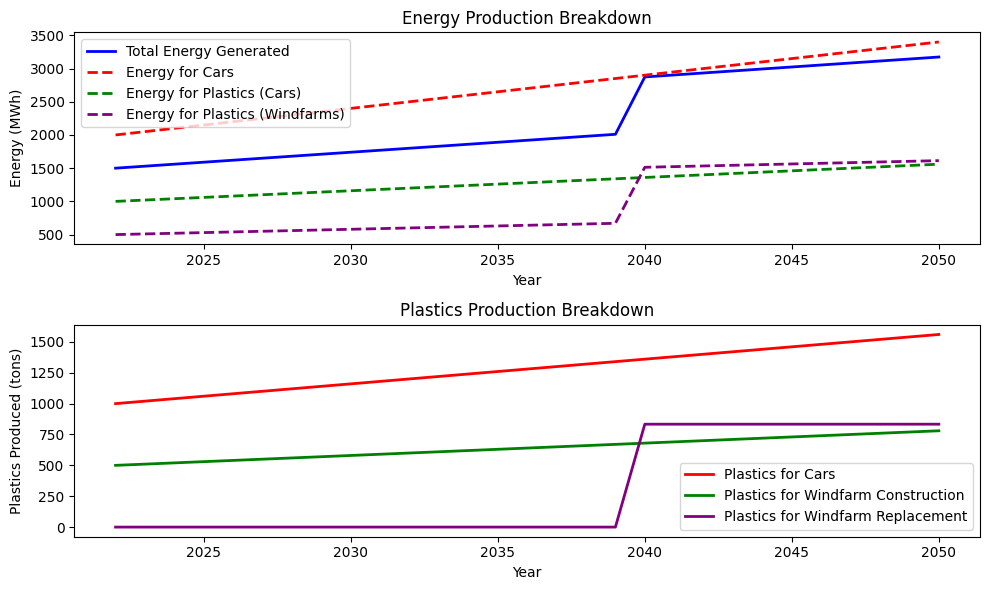

In [4]:
import matplotlib.pyplot as plt

# Solve the model
solver = SolverFactory('gurobi')
solver.solve(model)

# Collect data for plotting
years = list(range(2022, 2051))
car_plastics_produced = [model.car_plastics[year].value for year in model.years]
windfarm_plastics_produced = [model.windfarm_plastics[year].value for year in model.years]
replacement_plastics_produced = [model.replacement_plastics[year].value for year in model.years]
total_energy_generated = [model.energy_generated[year].value for year in model.years]
energy_for_cars = [demand_car_energy[year] for year in model.years]
energy_for_plastics_cars = [energy_cost_per_plastic_ton * model.car_plastics[year].value for year in model.years]
energy_for_plastics_windfarms = [energy_cost_per_plastic_ton * (model.windfarm_plastics[year].value + model.replacement_plastics[year].value) for year in model.years]

# Plotting
plt.figure(figsize=(10, 6))

# Energy Production Breakdown
plt.subplot(2, 1, 1)
plt.plot(years, total_energy_generated, label='Total Energy Generated', color='blue', linewidth=2)
plt.plot(years, energy_for_cars, label='Energy for Cars', color='red', linestyle='--', linewidth=2)
plt.plot(years, energy_for_plastics_cars, label='Energy for Plastics (Cars)', color='green', linestyle='--', linewidth=2)
plt.plot(years, energy_for_plastics_windfarms, label='Energy for Plastics (Windfarms)', color='purple', linestyle='--', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Energy (MWh)')
plt.title('Energy Production Breakdown')
plt.legend()

# Plastics Production Breakdown
plt.subplot(2, 1, 2)
plt.plot(years, car_plastics_produced, label='Plastics for Cars', color='red', linewidth=2)
plt.plot(years, windfarm_plastics_produced, label='Plastics for Windfarm Construction', color='green', linewidth=2)
plt.plot(years, replacement_plastics_produced, label='Plastics for Windfarm Replacement', color='purple', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Plastics Produced (tons)')
plt.title('Plastics Production Breakdown')
plt.legend()

plt.tight_layout()
plt.show()


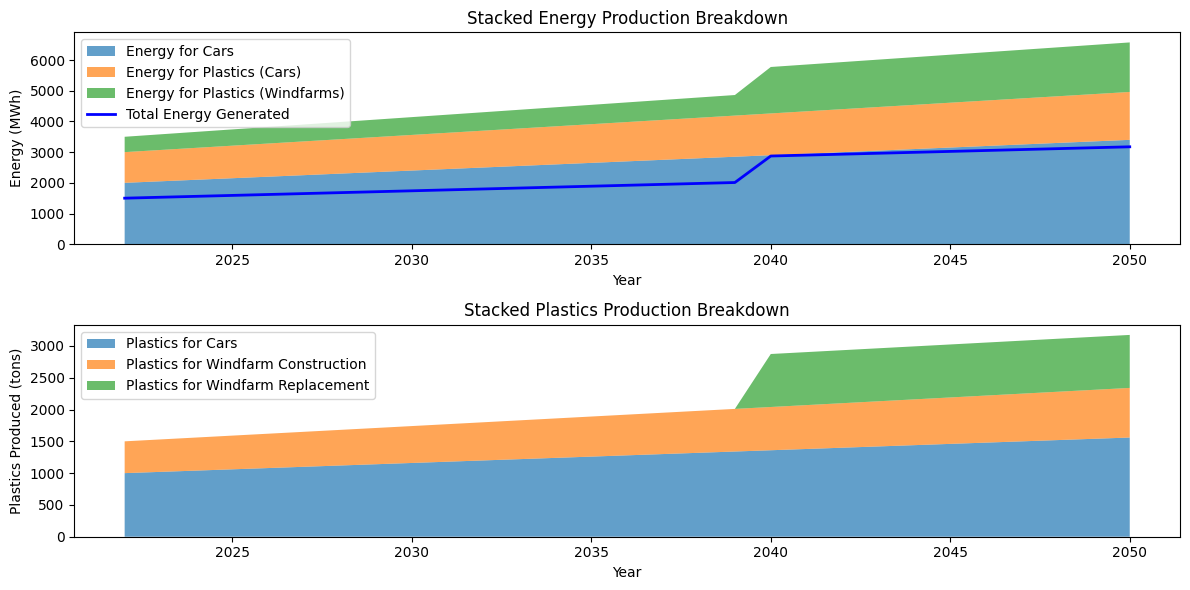

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Solve the model
solver = SolverFactory('gurobi')
solver.solve(model)

# Collect data for plotting
years = list(range(2022, 2051))
car_plastics_produced = [model.car_plastics[year].value for year in model.years]
windfarm_plastics_produced = [model.windfarm_plastics[year].value for year in model.years]
replacement_plastics_produced = [model.replacement_plastics[year].value for year in model.years]
total_energy_generated = [model.energy_generated[year].value for year in model.years]
energy_for_cars = [demand_car_energy[year] for year in model.years]
energy_for_plastics_cars = [energy_cost_per_plastic_ton * model.car_plastics[year].value for year in model.years]
energy_for_plastics_windfarms = [energy_cost_per_plastic_ton * (model.windfarm_plastics[year].value + model.replacement_plastics[year].value) for year in model.years]

# Plotting Stacked Energy Production
plt.figure(figsize=(12, 6))

# Stacked Energy Production
plt.subplot(2, 1, 1)
plt.stackplot(years, 
              energy_for_cars, 
              energy_for_plastics_cars, 
              energy_for_plastics_windfarms, 
              labels=['Energy for Cars', 'Energy for Plastics (Cars)', 'Energy for Plastics (Windfarms)'],
              alpha=0.7)

plt.plot(years, total_energy_generated, label='Total Energy Generated', color='blue', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Energy (MWh)')
plt.title('Stacked Energy Production Breakdown')
plt.legend(loc='upper left')

# Plotting Stacked Plastics Production
plt.subplot(2, 1, 2)
plt.stackplot(years, 
              car_plastics_produced, 
              windfarm_plastics_produced, 
              replacement_plastics_produced, 
              labels=['Plastics for Cars', 'Plastics for Windfarm Construction', 'Plastics for Windfarm Replacement'],
              alpha=0.7)

plt.xlabel('Year')
plt.ylabel('Plastics Produced (tons)')
plt.title('Stacked Plastics Production Breakdown')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


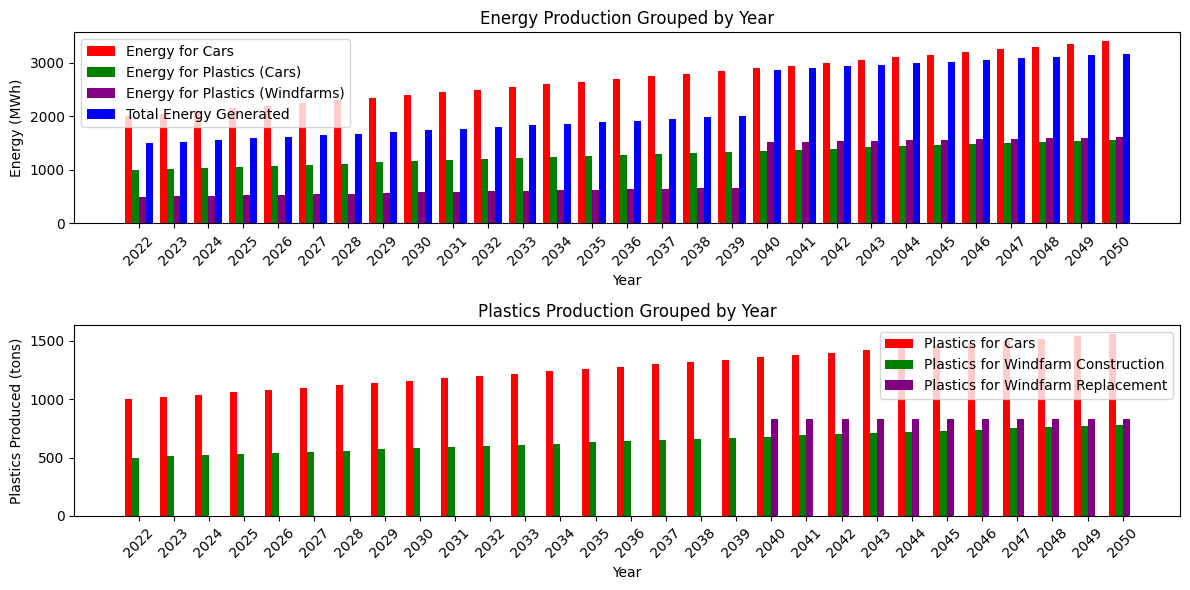

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Solve the model
solver = SolverFactory('gurobi')
solver.solve(model)

# Collect data for plotting
years = list(range(2022, 2051))
car_plastics_produced = [model.car_plastics[year].value for year in model.years]
windfarm_plastics_produced = [model.windfarm_plastics[year].value for year in model.years]
replacement_plastics_produced = [model.replacement_plastics[year].value for year in model.years]
total_energy_generated = [model.energy_generated[year].value for year in model.years]
energy_for_cars = [demand_car_energy[year] for year in model.years]
energy_for_plastics_cars = [energy_cost_per_plastic_ton * model.car_plastics[year].value for year in model.years]
energy_for_plastics_windfarms = [energy_cost_per_plastic_ton * (model.windfarm_plastics[year].value + model.replacement_plastics[year].value) for year in model.years]

# Set positions for the bars
bar_width = 0.2  # Width of each bar
index = np.arange(len(years))  # Position of bars on the x-axis

# Plotting Grouped Bar for Energy Production
plt.figure(figsize=(12, 6))

# Energy for Cars, Plastics for Cars, Plastics for Windfarms, Total Energy Generated
plt.subplot(2, 1, 1)
plt.bar(index - 1.5 * bar_width, energy_for_cars, bar_width, label='Energy for Cars', color='red')
plt.bar(index - 0.5 * bar_width, energy_for_plastics_cars, bar_width, label='Energy for Plastics (Cars)', color='green')
plt.bar(index + 0.5 * bar_width, energy_for_plastics_windfarms, bar_width, label='Energy for Plastics (Windfarms)', color='purple')
plt.bar(index + 1.5 * bar_width, total_energy_generated, bar_width, label='Total Energy Generated', color='blue')

plt.xlabel('Year')
plt.ylabel('Energy (MWh)')
plt.title('Energy Production Grouped by Year')
plt.xticks(index, years, rotation=45)
plt.legend()

# Plotting Grouped Bar for Plastics Production
plt.subplot(2, 1, 2)

# Plastics for Cars, Plastics for Windfarm Construction, Plastics for Windfarm Replacement
plt.bar(index - 1.5 * bar_width, car_plastics_produced, bar_width, label='Plastics for Cars', color='red')
plt.bar(index - 0.5 * bar_width, windfarm_plastics_produced, bar_width, label='Plastics for Windfarm Construction', color='green')
plt.bar(index + 0.5 * bar_width, replacement_plastics_produced, bar_width, label='Plastics for Windfarm Replacement', color='purple')

plt.xlabel('Year')
plt.ylabel('Plastics Produced (tons)')
plt.title('Plastics Production Grouped by Year')
plt.xticks(index, years, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()


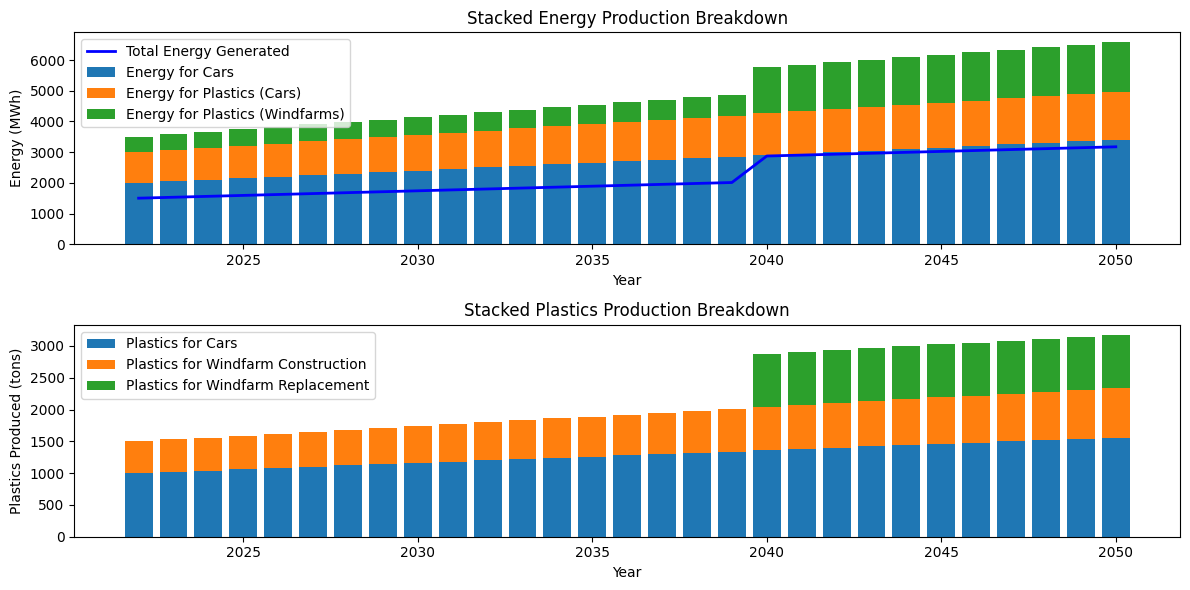

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from pyomo.environ import SolverFactory

# Solve the model
solver = SolverFactory('gurobi')
solver.solve(model)

# Collect data for plotting
years = list(range(2022, 2051))
car_plastics_produced = [model.car_plastics[year].value for year in model.years]
windfarm_plastics_produced = [model.windfarm_plastics[year].value for year in model.years]
replacement_plastics_produced = [model.replacement_plastics[year].value for year in model.years]
total_energy_generated = [model.energy_generated[year].value for year in model.years]
energy_for_cars = [demand_car_energy[year] for year in model.years]
energy_for_plastics_cars = [energy_cost_per_plastic_ton * model.car_plastics[year].value for year in model.years]
energy_for_plastics_windfarms = [energy_cost_per_plastic_ton * (model.windfarm_plastics[year].value + model.replacement_plastics[year].value) for year in model.years]

# Plotting Stacked Bar for Energy Production
plt.figure(figsize=(12, 6))

# Stacked Energy Production
plt.subplot(2, 1, 1)

# Calculate the bottom positions for each energy source
plt.bar(years, energy_for_cars, label='Energy for Cars')
plt.bar(years, energy_for_plastics_cars, label='Energy for Plastics (Cars)', bottom=energy_for_cars)
plt.bar(years, energy_for_plastics_windfarms, label='Energy for Plastics (Windfarms)', bottom=np.array(energy_for_cars) + np.array(energy_for_plastics_cars))

plt.plot(years, total_energy_generated, label='Total Energy Generated', color='blue', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Energy (MWh)')
plt.title('Stacked Energy Production Breakdown')
plt.legend(loc='upper left')

# Plotting Stacked Bar for Plastics Production
plt.subplot(2, 1, 2)

# Calculate the bottom positions for each category of plastics production
plt.bar(years, car_plastics_produced, label='Plastics for Cars')
plt.bar(years, windfarm_plastics_produced, label='Plastics for Windfarm Construction', bottom=car_plastics_produced)
plt.bar(years, replacement_plastics_produced, label='Plastics for Windfarm Replacement', bottom=np.array(car_plastics_produced) + np.array(windfarm_plastics_produced))

plt.xlabel('Year')
plt.ylabel('Plastics Produced (tons)')
plt.title('Stacked Plastics Production Breakdown')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()
